# Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sys.path.append(os.path.abspath(".."))

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_plot(name):
    plt.savefig(f"{FIG_DIR}/{name}.png", bbox_inches="tight", dpi=300)

# Load Data

In [112]:
df = pd.read_csv("../data/raw/train.csv")
df.columns = df.columns.str.strip()

# Column Renaming

In [113]:
df.rename(columns={
    "ID": "order_id",
    "Delivery_person_ID": "driver_id",
    "Delivery_person_Age": "driver_age",
    "Delivery_person_Ratings": "driver_rating",
    "Restaurant_latitude": "restaurant_latitude",
    "Restaurant_longitude": "restaurant_longitude",
    "Delivery_location_latitude": "delivery_latitude",
    "Delivery_location_longitude": "delivery_longitude",
    "Order_Date": "order_date",
    "Time_Orderd": "order_time",
    "Time_Order_picked": "pickup_time",
    "Weatherconditions": "weather",
    "Road_traffic_density": "traffic_density",
    "Vehicle_condition": "vehicle_condition",
    "Type_of_order": "order_type",
    "Type_of_vehicle": "vehicle_type",
    "multiple_deliveries": "num_deliveries",
    "Festival": "is_festival",
    "City": "city",
    "Time_taken(min)": "delivery_time_min"
}, inplace=True)

# Data Cleaning
## Replace Invalid Missing Values

In [114]:
df.replace(['NaN', 'NaN ', 'nan', "conditions NaN"], np.nan, inplace=True)

,order_id,driver_id,driver_age,driver_rating,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,pickup_time,weather,traffic_density,vehicle_condition,order_type,vehicle_type,num_deliveries,is_festival,city,delivery_time_min
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


# Strip Whitespace

In [115]:
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].str.strip()

## Fix Target Variable

In [116]:
df["delivery_time_min"] = df["delivery_time_min"].str.extract(r'(\d+)')
df["delivery_time_min"] = pd.to_numeric(df["delivery_time_min"], errors='coerce')

## Fix Ratings

In [117]:
df["driver_rating"] = pd.to_numeric(df["driver_rating"], errors='coerce')
df.loc[df["driver_rating"] > 5, "driver_rating"] = np.nan

## Convert Date & Time

In [118]:
df["order_date"] = pd.to_datetime(df["order_date"], format="%d-%m-%Y", errors='coerce')

df["order_time"] = pd.to_datetime(df["order_time"], format="%H:%M:%S", errors='coerce')
df["pickup_time"] = pd.to_datetime(df["pickup_time"], format="%H:%M:%S", errors='coerce')

## Handle Numeric Missing Values

In [119]:
num_cols = ["driver_age", "driver_rating", "num_deliveries"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

df["num_deliveries"] = df["num_deliveries"].astype(int)

## Handle Categorical Missing Values

In [120]:
cat_cols = [
    "weather", "traffic_density",
    "order_type", "vehicle_type",
    "is_festival", "city"
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0]).astype("category")

# Remove conditions from weather

In [121]:
df["weather"] = df["weather"].str.replace("conditions ", "", regex=False).str.strip()
print(df["weather"].unique())

<StringArray>
['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy']
Length: 6, dtype: str


# Feature Engineering
## Distance Calculation

In [122]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine(
    df["restaurant_latitude"],
    df["restaurant_longitude"],
    df["delivery_latitude"],
    df["delivery_longitude"]
)

## Time Features

In [123]:
df["order_hour"] = df["order_time"].dt.hour
df["order_day"] = df["order_date"].dt.day_name()
df["is_weekend"] = df["order_day"].isin(["Saturday", "Sunday"]).astype(int)

df["is_peak_hour"] = df["order_hour"].isin(
    [12,13,14,15,18,19,20,21,22]
).astype(int)

In [124]:
# Convert datetime columns
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["order_time"] = pd.to_datetime(df["order_time"], errors="coerce")
df["pickup_time"] = pd.to_datetime(df["pickup_time"], errors="coerce")

# Convert categorical columns
cat_cols = [
    "weather", "traffic_density",
    "order_type", "vehicle_type",
    "is_festival", "city", "order_day"
]

for col in cat_cols:
    df[col] = df[col].astype("category")

# Convert order_hour to int
df["order_hour"] = df["order_hour"].astype("Int64")

In [125]:
df.dtypes

order_id                           str
driver_id                          str
driver_age                     float64
driver_rating                  float64
restaurant_latitude            float64
restaurant_longitude           float64
delivery_latitude              float64
delivery_longitude             float64
order_date              datetime64[us]
order_time              datetime64[us]
pickup_time             datetime64[us]
weather                       category
traffic_density               category
vehicle_condition                int64
order_type                    category
vehicle_type                  category
num_deliveries                   int64
is_festival                   category
city                          category
delivery_time_min                int64
distance_km                    float64
order_hour                       Int64
order_day                     category
is_weekend                       int64
is_peak_hour                     int64
dtype: object

# Outlier Handling
## Distance Outliers

In [126]:
df['distance_km'].describe()

count    45593.000000
mean        99.303911
std       1099.731281
min          1.465067
25%          4.663493
50%          9.264281
75%         13.763977
max      19692.674606
Name: distance_km, dtype: float64

In [127]:
upper_limit = df["distance_km"].quantile(0.99)
df = df[df["distance_km"] <= upper_limit]
df['distance_km'].describe()

count    45140.000000
mean         9.729921
std          5.604387
min          1.465067
25%          4.663345
50%          9.220148
75%         13.681416
max         20.968889
Name: distance_km, dtype: float64

## Driver Age Validation

In [128]:
df['driver_age'].describe()

count    45140.000000
mean        29.575964
std          5.691490
min         15.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         50.000000
Name: driver_age, dtype: float64

In [144]:
df = df[(df["driver_age"] >= 18) & (df["driver_age"] <= 40)]
df['driver_age'].describe()

count    45082.000000
mean        29.571425
std          5.659078
min         20.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         39.000000
Name: driver_age, dtype: float64

# Save Clean Data

In [145]:
df.to_csv("../data/processed/cleaned_delivery_data.csv", index=False)

# CLEANED DATA EDA

In [146]:
from src.data_preprocessing import load_clean_data

df = load_clean_data("../data/processed/cleaned_delivery_data.csv")
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (45082, 25)


,order_id,driver_id,driver_age,driver_rating,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,pickup_time,weather,traffic_density,vehicle_condition,order_type,vehicle_type,num_deliveries,is_festival,city,delivery_time_min,distance_km,order_hour,order_day,is_weekend,is_peak_hour
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,1900-01-01 11:30:00,1900-01-01 11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24,3.025149,11,Saturday,1,0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,1900-01-01 19:45:00,1900-01-01 19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33,20.183530,19,Friday,0,1
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,1900-01-01 08:30:00,1900-01-01 08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26,1.552758,8,Saturday,1,0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,1900-01-01 18:00:00,1900-01-01 18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21,7.790401,18,Tuesday,0,1
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,1900-01-01 13:30:00,1900-01-01 13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30,6.210138,13,Saturday,1,1


In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45082 entries, 0 to 45081
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_id              45082 non-null  str           
 1   driver_id             45082 non-null  str           
 2   driver_age            45082 non-null  float64       
 3   driver_rating         45082 non-null  float64       
 4   restaurant_latitude   45082 non-null  float64       
 5   restaurant_longitude  45082 non-null  float64       
 6   delivery_latitude     45082 non-null  float64       
 7   delivery_longitude    45082 non-null  float64       
 8   order_date            45082 non-null  datetime64[us]
 9   order_time            43685 non-null  datetime64[us]
 10  pickup_time           45082 non-null  datetime64[us]
 11  weather               45082 non-null  category      
 12  traffic_density       45082 non-null  category      
 13  vehicle_condition     45082

In [ ]:
# =========================
# NUMERICAL CORRELATION
# =========================

num_df = df.select_dtypes(include=[np.number])

corr_num = num_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_num,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Numerical Features Correlation Matrix")
save_plot("corr_numerical")
plt.show()

In [ ]:
# =========================
# CATEGORICAL CORRELATION
# =========================

cat_df = df.select_dtypes(include=["object", "category"]).copy()

# Encode categories
for col in cat_df.columns:
    cat_df[col] = cat_df[col].astype("category").cat.codes

corr_cat = cat_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_cat,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Categorical Features Correlation Matrix (Encoded)")
save_plot("corr_categorical")
plt.show()

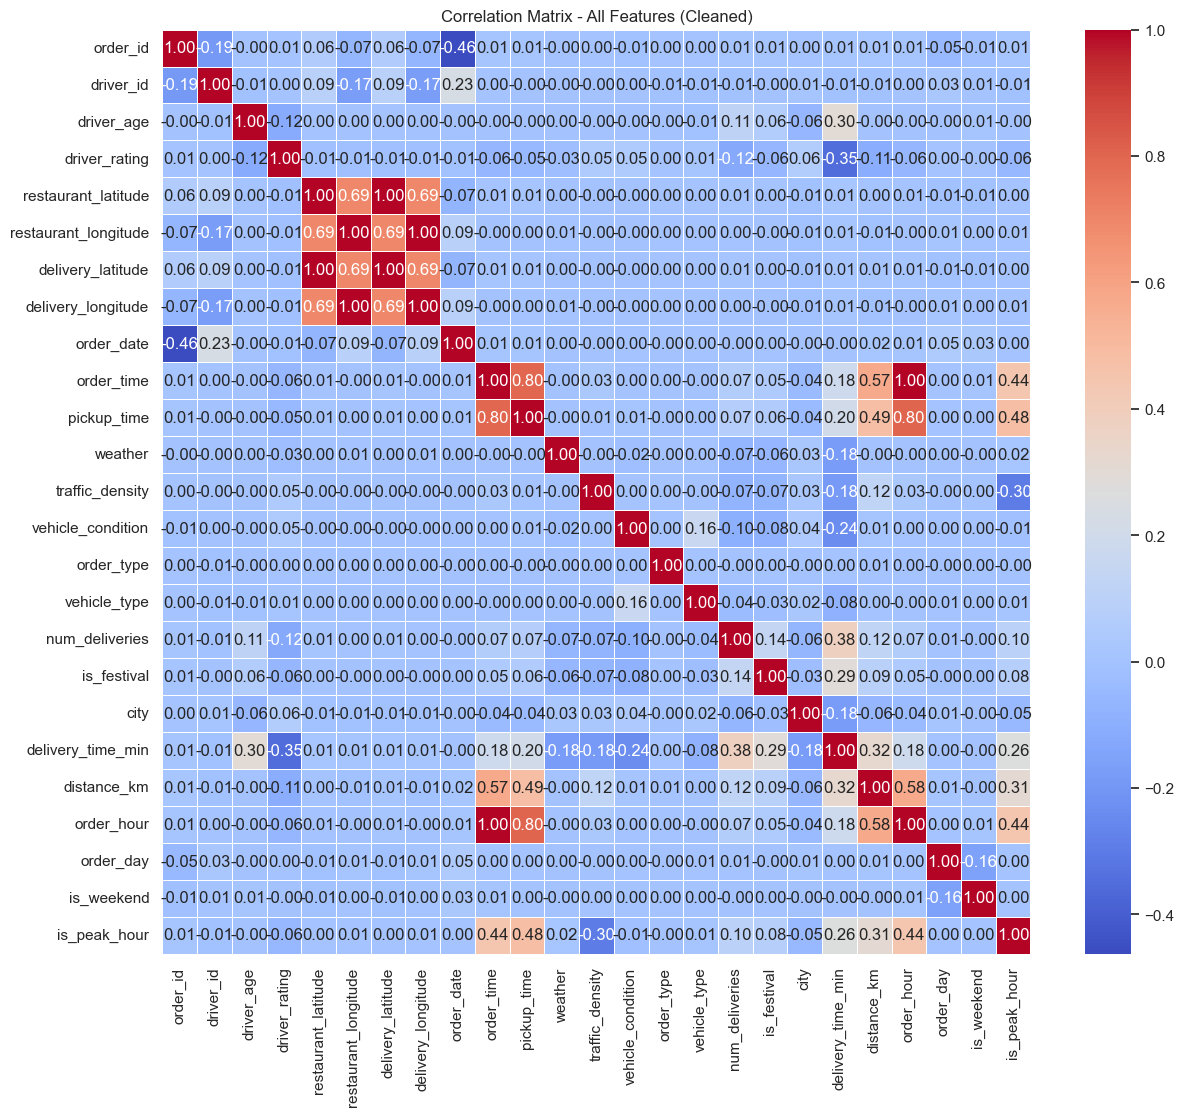

In [148]:
df_corr = df.copy()

# Encode categorical + string columns properly (fix warning)
for col in df_corr.select_dtypes(include=["object", "category", "string"]).columns:
    df_corr[col] = df_corr[col].astype("category").cat.codes

# Correlation matrix
corr_matrix = df_corr.corr()

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,        
    fmt=".2f",         
    linewidths=0.5
)

plt.title("Correlation Matrix - All Features (Cleaned)")
save_plot("correlation_matrix_all_features_cleaned")
plt.show()

In [ ]:
def anova_test(df, cat_col, target_col="delivery_time_min"):
    groups = [
        group[target_col].dropna().values
        for name, group in df.groupby(cat_col)
        if len(group) > 1
    ]
    
    if len(groups) < 2:
        return np.nan, np.nan
    
    f_stat, p_value = f_oneway(*groups)
    return f_stat, p_value

In [ ]:
# =========================
# ANOVA TEST
# =========================

cat_cols = [
    "weather", "traffic_density",
    "order_type", "vehicle_type",
    "is_festival", "city",
    "order_day", "is_peak_hour", "is_weekend"
]

anova_results = []

for col in cat_cols:
    f_stat, p_val = anova_test(df, col)
    
    anova_results.append({
        "feature": col,
        "F_stat": f_stat,
        "p_value": p_val
    })

anova_df = pd.DataFrame(anova_results)

# Sort by significance
anova_df = anova_df.sort_values(by="p_value")

print(anova_df)

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=anova_df,
    x="F_stat",
    y="feature"
)

plt.title("ANOVA Feature Importance (Categorical → Delivery Time)")
save_plot("anova_feature_importance")
plt.show()

In [ ]:
tukey_traffic = tukey_test(df, "traffic_density")
print(tukey_traffic)

In [ ]:
tukey_weather = tukey_test(df, "weather")
print(tukey_weather)

In [ ]:
def tukey_to_df(tukey_result):
    return pd.DataFrame(
        data=tukey_result.summary().data[1:],
        columns=tukey_result.summary().data[0]
    )

In [ ]:
traffic_df = tukey_to_df(tukey_traffic)
print(traffic_df.head())

In [ ]:
tukey_peak = tukey_test(df, "is_peak_hour")
print(tukey_peak)

In [ ]:
def tukey_test(df, cat_col, target_col="delivery_time_min"):
    data = df[[cat_col, target_col]].dropna()
    
    tukey = pairwise_tukeyhsd(
        endog=data[target_col],
        groups=data[cat_col],
        alpha=0.05
    )
    
    return tukey

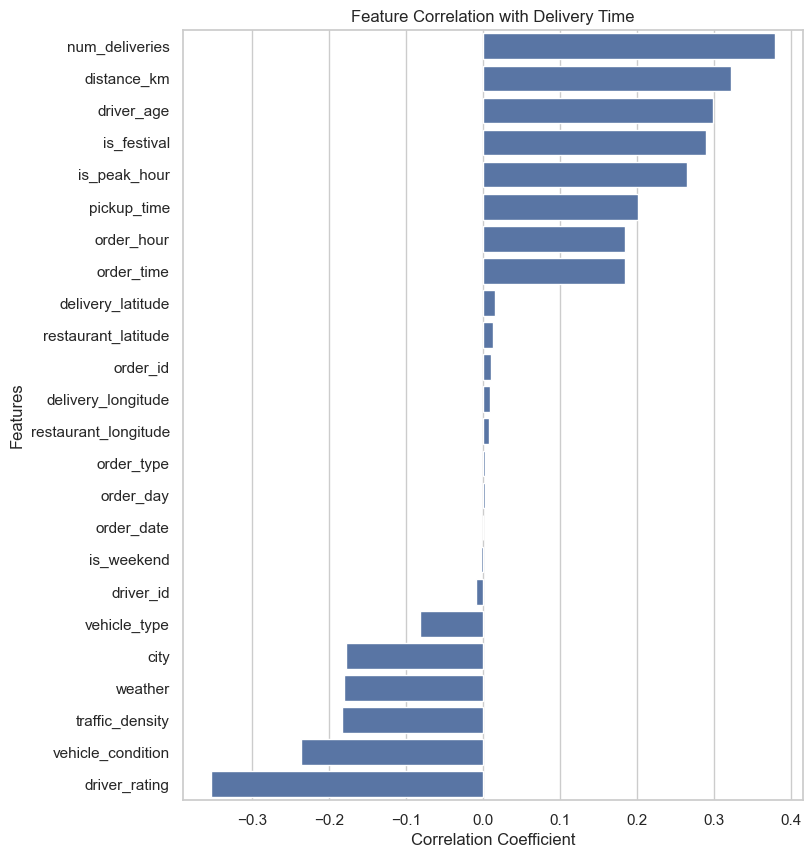

In [149]:
df_corr = df.copy()

# Encode categorical + string columns
for col in df_corr.select_dtypes(include=["object", "category", "string"]).columns:
    df_corr[col] = df_corr[col].astype("category").cat.codes

# Compute correlation
corr_matrix = df_corr.corr()

# Extract correlation with target
target_corr = corr_matrix["delivery_time_min"].sort_values(ascending=False)
target_corr = target_corr.drop("delivery_time_min")

# Plot
plt.figure(figsize=(8, 10))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)

plt.title("Feature Correlation with Delivery Time")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

save_plot("correlation_with_target_cleaned")
plt.show()

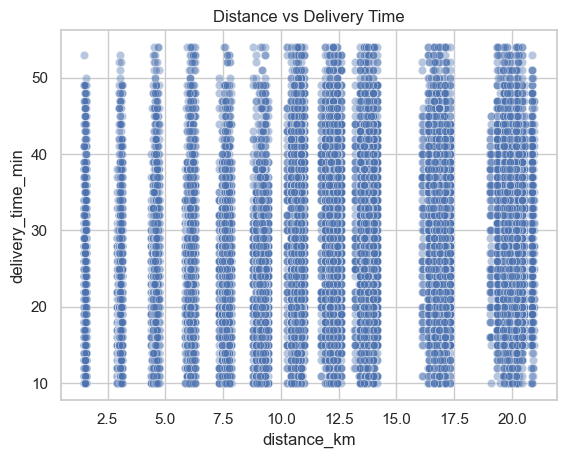

In [150]:
plt.figure()
sns.scatterplot(data=df, x="distance_km", y="delivery_time_min", alpha=0.4)
plt.title("Distance vs Delivery Time")
save_plot("distance_vs_delivery_time_cleaned")
plt.show()

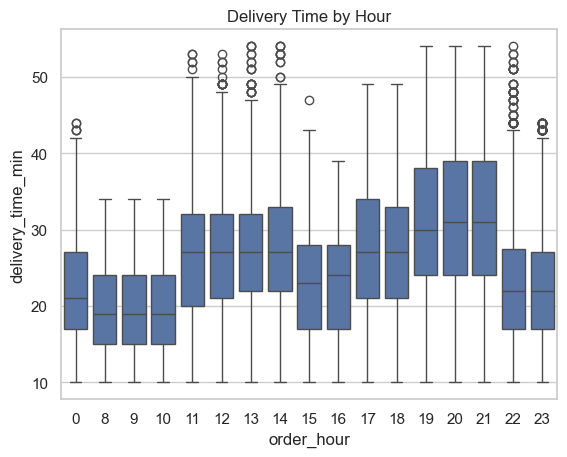

In [151]:
plt.figure()
sns.boxplot(data=df, x="order_hour", y="delivery_time_min")
plt.title("Delivery Time by Hour")
save_plot("delivery_time_by_hour")
plt.show()

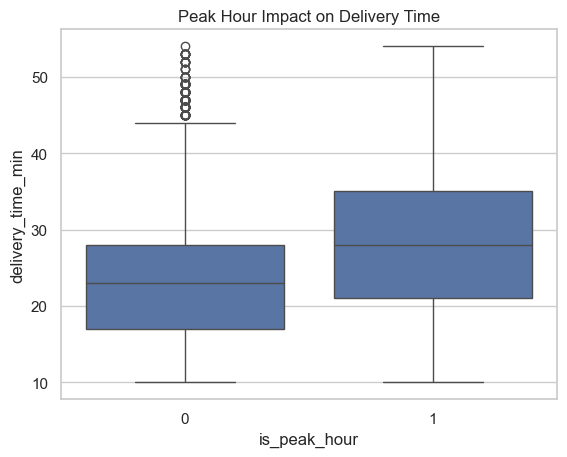

In [152]:
plt.figure()
sns.boxplot(data=df, x="is_peak_hour", y="delivery_time_min")
plt.title("Peak Hour Impact on Delivery Time")
save_plot("peak_hour_impact")
plt.show()

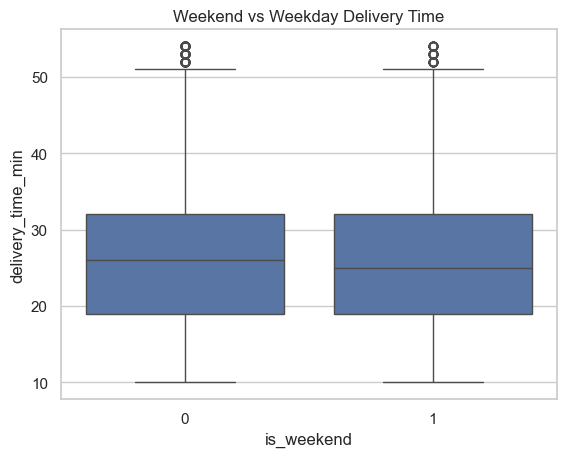

In [153]:
plt.figure()
sns.boxplot(data=df, x="is_weekend", y="delivery_time_min")
plt.title("Weekend vs Weekday Delivery Time")
save_plot("weekend_impact")
plt.show()

# TRAFFIC & WEATHER IMPACT (CRITICAL INSIGHT)

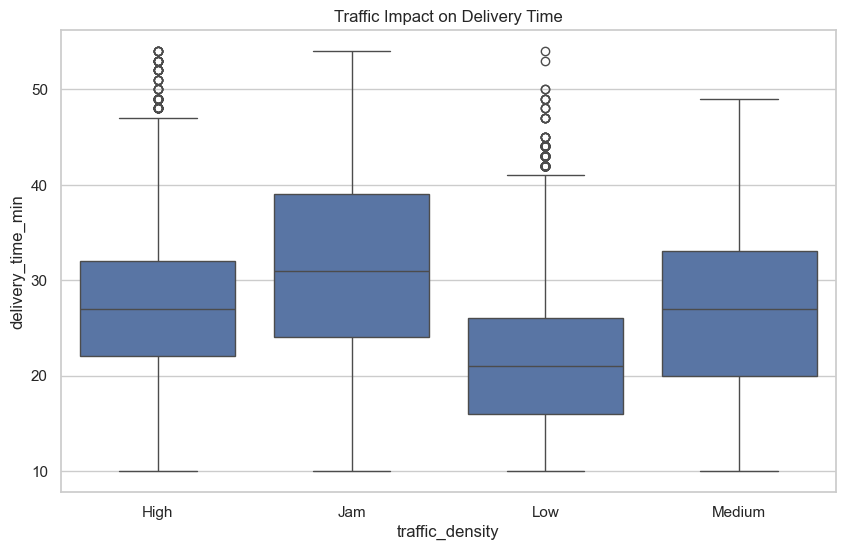

In [154]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="traffic_density", y="delivery_time_min")
plt.title("Traffic Impact on Delivery Time")
save_plot("traffic_impact")
plt.show()

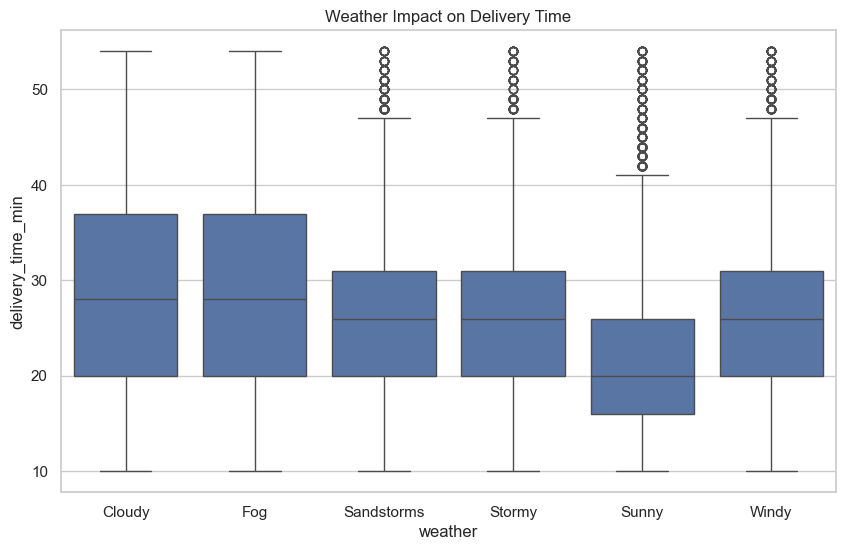

In [155]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="weather", y="delivery_time_min")
plt.title("Weather Impact on Delivery Time")
save_plot("weather_impact")
plt.show()

# MULTIPLE DELIVERIES IMPACT

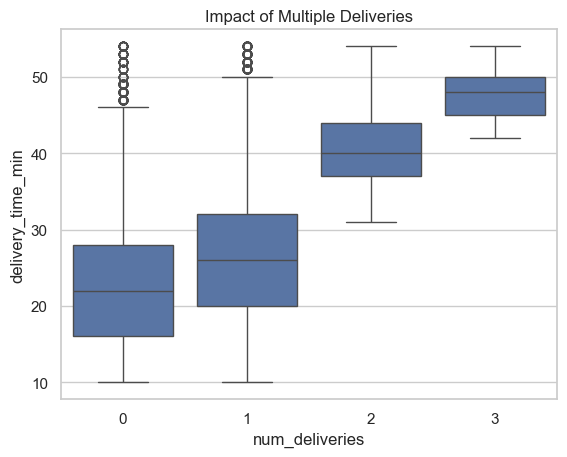

In [156]:
plt.figure()
sns.boxplot(data=df, x="num_deliveries", y="delivery_time_min")
plt.title("Impact of Multiple Deliveries")
save_plot("multiple_deliveries_impact")
plt.show()

# DRIVER PERFORMANCE

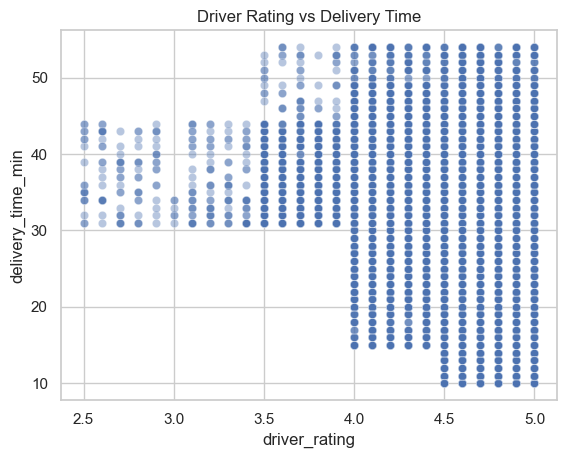

In [157]:
plt.figure()
sns.scatterplot(data=df, x="driver_rating", y="delivery_time_min", alpha=0.4)
plt.title("Driver Rating vs Delivery Time")
save_plot("driver_rating_vs_delivery_time_cleaned")
plt.show()

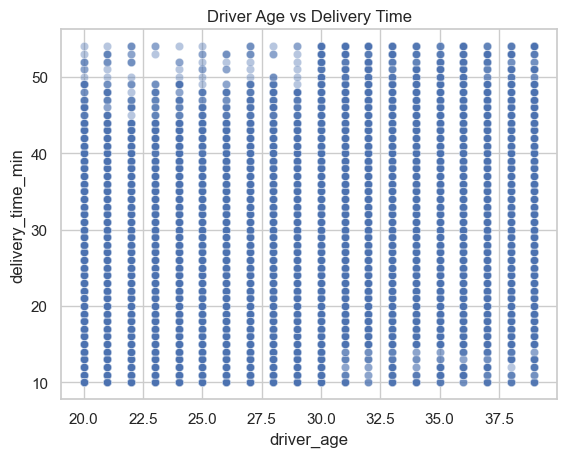

In [158]:
plt.figure()
sns.scatterplot(data=df, x="driver_age", y="delivery_time_min", alpha=0.4)
plt.title("Driver Age vs Delivery Time")
save_plot("driver_age_vs_delivery_time_cleaned")
plt.show()

In [159]:
# =========================
# FINAL DATA QUALITY CHECK
# =========================

print("🔹 Dataset Shape:")
print(df.shape)

print("\n🔹 Missing Values:")
missing = df.isnull().sum()
print(missing)
print("Total Missing:", missing.sum())

print("\n🔹 Duplicate Rows:")
print(df.duplicated().sum())

print("\n🔹 Data Types:")
print(df.dtypes)

# =========================
# RANGE CHECKS
# =========================

print("\n🔹 Numerical Range Checks:")

print("Driver Age Range:", df["driver_age"].min(), "-", df["driver_age"].max())
print("Driver Rating Range:", df["driver_rating"].min(), "-", df["driver_rating"].max())
print("Delivery Time Range:", df["delivery_time_min"].min(), "-", df["delivery_time_min"].max())
print("Distance Range:", df["distance_km"].min(), "-", df["distance_km"].max())

# =========================
# CATEGORICAL CONSISTENCY
# =========================

print("\n🔹 Categorical Unique Values:")

cat_cols = [
    "weather", "traffic_density",
    "order_type", "vehicle_type",
    "is_festival", "city", "order_day"
]

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())

# =========================
# FEATURE ENGINEERING CHECK
# =========================

print("\n🔹 Engineered Features Check:")

engineered_cols = ["distance_km", "order_hour", "is_weekend", "is_peak_hour"]

print(df[engineered_cols].head())

print("\nMissing in engineered features:")
print(df[engineered_cols].isnull().sum())

# =========================
# LOGICAL CHECKS
# =========================

print("\n🔹 Logical Validations:")

print("Any negative delivery time:", (df["delivery_time_min"] < 0).sum())
print("Any negative distance:", (df["distance_km"] < 0).sum())
print("Invalid ratings (>5):", (df["driver_rating"] > 5).sum())

# =========================
# SUMMARY STATS
# =========================

print("\n🔹 Summary Statistics:")
display(df.describe())

🔹 Dataset Shape:
(45082, 25)

🔹 Missing Values:
order_id                   0
driver_id                  0
driver_age                 0
driver_rating              0
restaurant_latitude        0
restaurant_longitude       0
delivery_latitude          0
delivery_longitude         0
order_date                 0
order_time              1397
pickup_time                0
weather                    0
traffic_density            0
vehicle_condition          0
order_type                 0
vehicle_type               0
num_deliveries             0
is_festival                0
city                       0
delivery_time_min          0
distance_km                0
order_hour              1397
order_day                  0
is_weekend                 0
is_peak_hour               0
dtype: int64
Total Missing: 2794

🔹 Duplicate Rows:
0

🔹 Data Types:
order_id                           str
driver_id                          str
driver_age                     float64
driver_rating                  float64
re

,driver_age,driver_rating,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,pickup_time,vehicle_condition,num_deliveries,delivery_time_min,distance_km,order_hour,is_weekend,is_peak_hour
count,45082.000000,45082.000000,45082.000000,45082.000000,45082.000000,45082.000000,45082,43685,45082,45082.000000,45082.000000,45082.000000,45082.000000,43685.0,45082.000000,45082.000000
mean,29.571425,4.637676,17.374183,70.718150,17.437755,70.781722,2022-03-13 19:06:50.292356,1900-01-01 17:54:53.187594,1900-01-01 17:37:12.451977,1.014840,0.750388,26.298523,9.729653,17.422159,0.275143,0.579100
min,20.000000,2.500000,0.000000,0.000000,0.010000,0.010000,2022-02-11 00:00:00,1900-01-01 00:00:00,1900-01-01 00:00:00,0.000000,0.000000,10.000000,1.465067,0.0,0.000000,0.000000
25%,25.000000,4.500000,12.934179,73.170283,12.985662,73.277753,2022-03-05 00:00:00,1900-01-01 15:25:00,1900-01-01 14:35:00,0.000000,0.000000,19.000000,4.663345,15.0,0.000000,0.000000
50%,30.000000,4.700000,18.554382,75.898497,18.631440,75.997522,2022-03-15 00:00:00,1900-01-01 19:15:00,1900-01-01 19:10:00,1.000000,1.000000,26.000000,9.220148,19.0,0.000000,1.000000
75%,34.000000,4.800000,22.732225,78.044095,22.782634,78.098890,2022-03-27 00:00:00,1900-01-01 21:35:00,1900-01-01 21:35:00,2.000000,1.000000,32.000000,13.681416,21.0,1.000000,1.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-04-06 00:00:00,1900-01-01 23:55:00,1900-01-01 23:55:00,3.000000,3.000000,54.000000,20.968889,23.0,1.000000,1.000000
std,5.659078,0.308270,7.337966,21.193789,7.339292,21.193965,NaN,NaN,NaN,0.830945,0.567647,9.385527,5.604606,4.818604,0.446591,0.493709


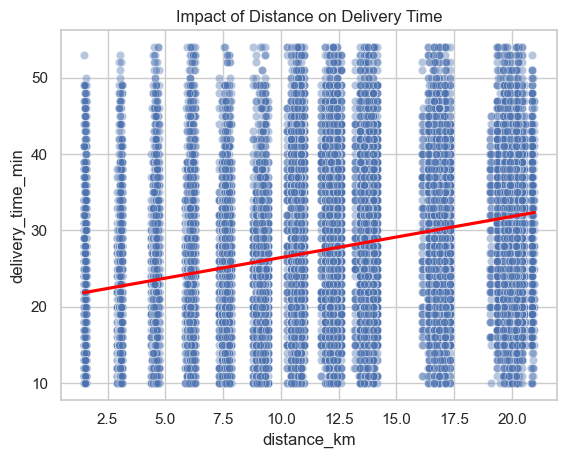

In [160]:
plt.figure()
sns.scatterplot(data=df, x="distance_km", y="delivery_time_min", alpha=0.4)
sns.regplot(data=df, x="distance_km", y="delivery_time_min", scatter=False, color="red")
plt.title("Impact of Distance on Delivery Time")
save_plot("eda_distance_vs_time")
plt.show()

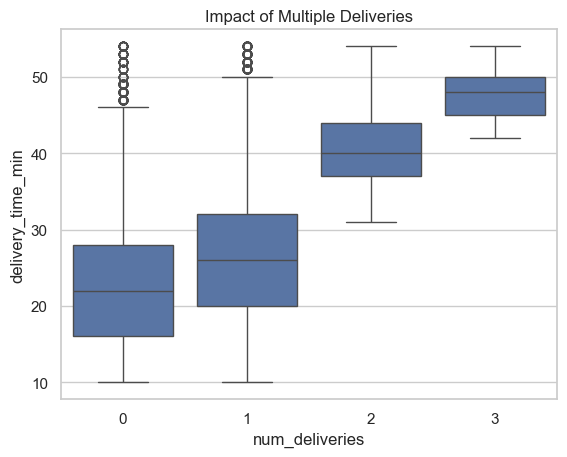

In [161]:
plt.figure()
sns.boxplot(data=df, x="num_deliveries", y="delivery_time_min")
plt.title("Impact of Multiple Deliveries")
save_plot("eda_num_deliveries")
plt.show()

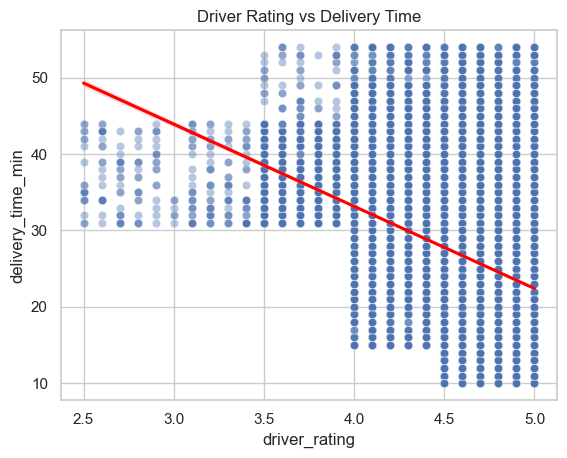

In [162]:
plt.figure()
sns.scatterplot(data=df, x="driver_rating", y="delivery_time_min", alpha=0.4)
sns.regplot(data=df, x="driver_rating", y="delivery_time_min", scatter=False, color="red")
plt.title("Driver Rating vs Delivery Time")
save_plot("eda_driver_rating")
plt.show()

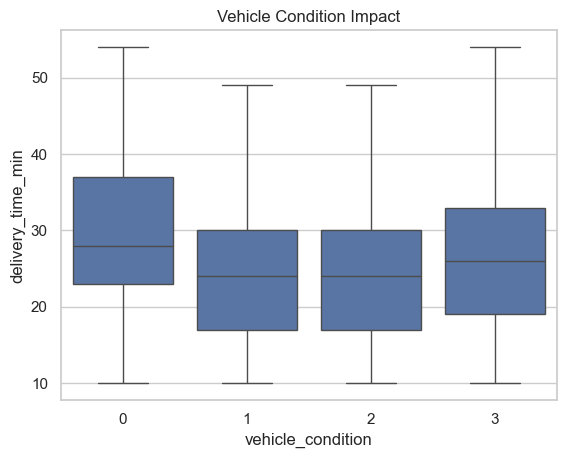

In [163]:
plt.figure()
sns.boxplot(data=df, x="vehicle_condition", y="delivery_time_min")
plt.title("Vehicle Condition Impact")
save_plot("eda_vehicle_condition")
plt.show()

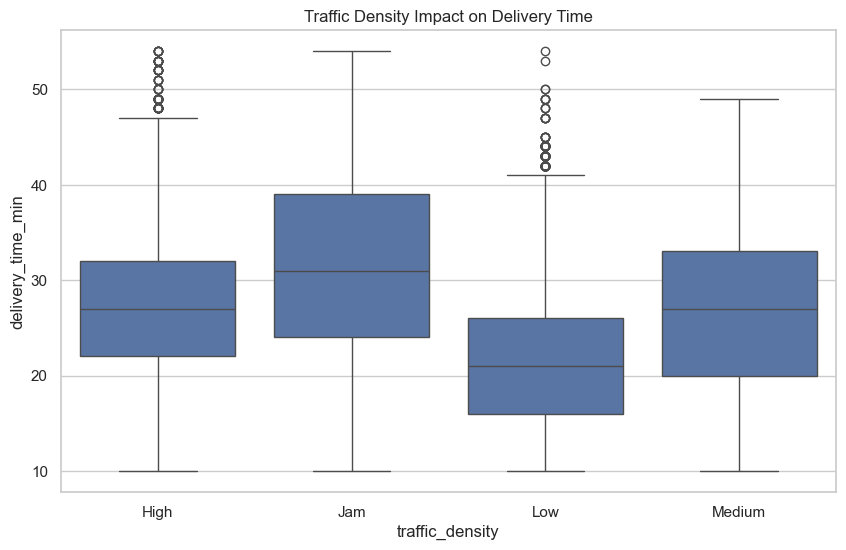

In [164]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="traffic_density", y="delivery_time_min")
plt.title("Traffic Density Impact on Delivery Time")
save_plot("eda_traffic")
plt.show()

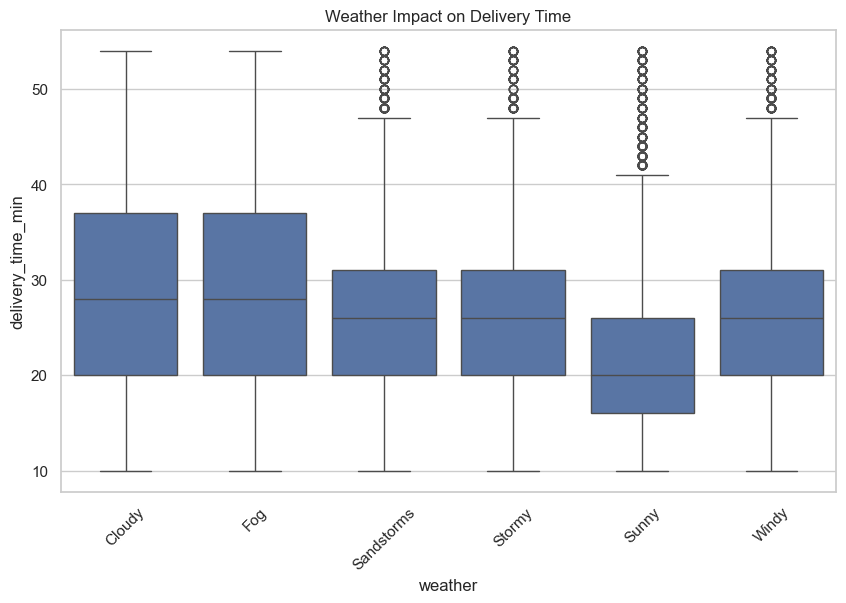

In [165]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="weather", y="delivery_time_min")
plt.xticks(rotation=45)
plt.title("Weather Impact on Delivery Time")
save_plot("eda_weather")
plt.show()

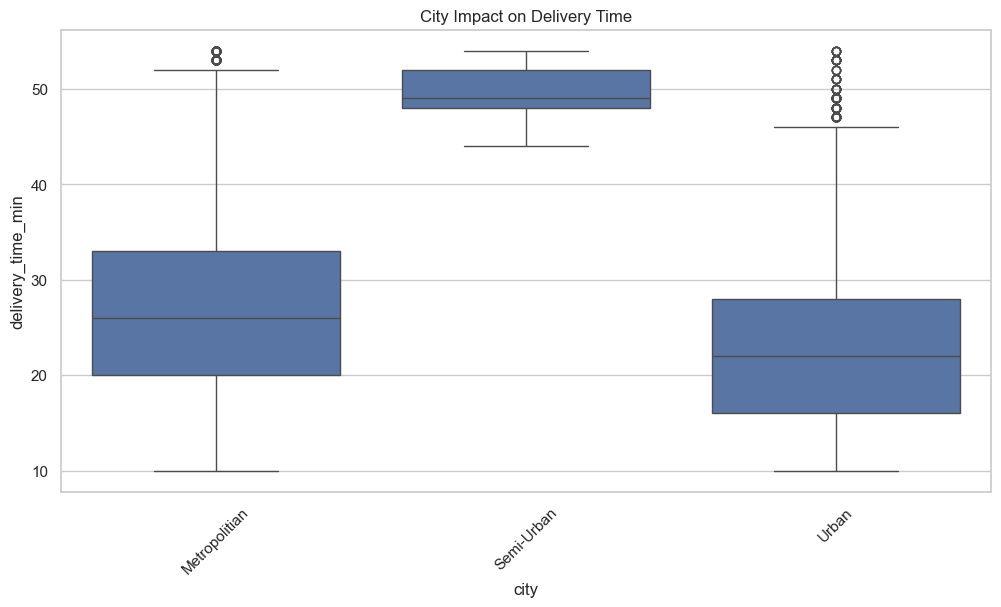

In [166]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="city", y="delivery_time_min")
plt.xticks(rotation=45)
plt.title("City Impact on Delivery Time")
save_plot("eda_city")
plt.show()

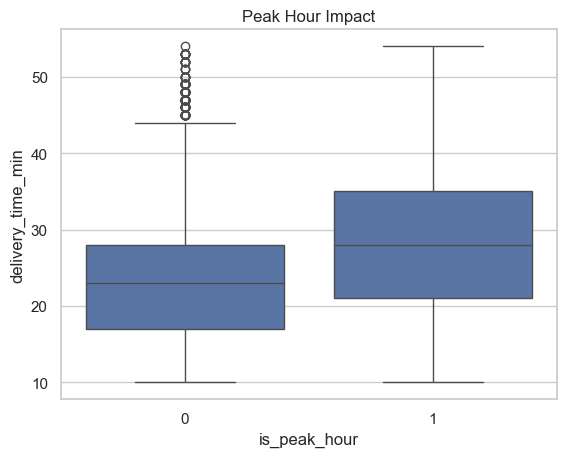

In [167]:
plt.figure()
sns.boxplot(data=df, x="is_peak_hour", y="delivery_time_min")
plt.title("Peak Hour Impact")
save_plot("eda_peak_hour")
plt.show()

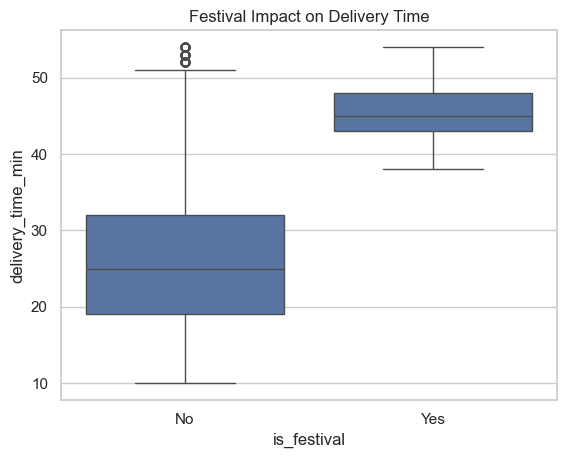

In [168]:
plt.figure()
sns.boxplot(data=df, x="is_festival", y="delivery_time_min")
plt.title("Festival Impact on Delivery Time")
save_plot("eda_festival")
plt.show()

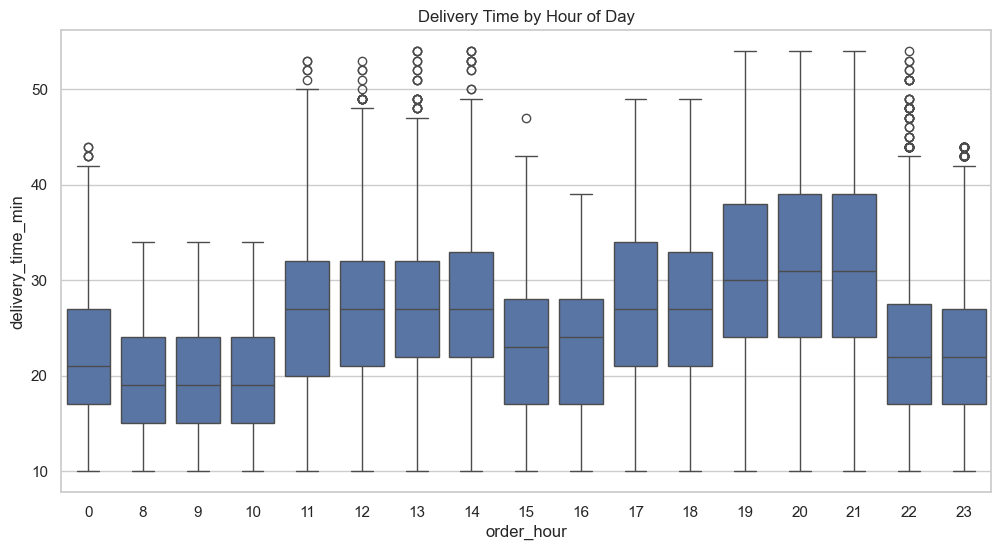

In [169]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="order_hour", y="delivery_time_min")
plt.title("Delivery Time by Hour of Day")
save_plot("eda_order_hour")
plt.show()

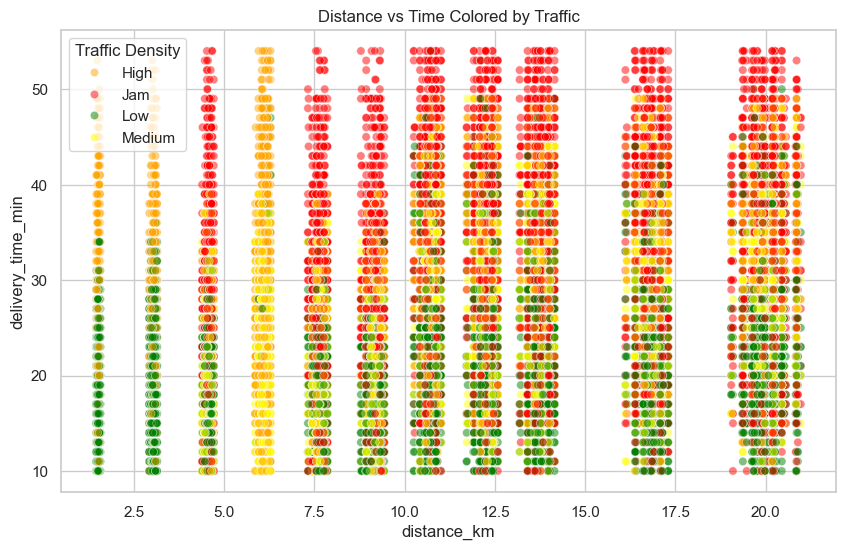

In [172]:
plt.figure(figsize=(10,6))

# Define custom colors
traffic_palette = {
    "Low": "green",
    "Medium": "yellow",
    "High": "orange",
    "Jam": "red"
}

sns.scatterplot(
    data=df,
    x="distance_km",
    y="delivery_time_min",
    hue="traffic_density",
    palette=traffic_palette,
    alpha=0.5
)

plt.title("Distance vs Time Colored by Traffic")
plt.legend(title="Traffic Density")
save_plot("eda_distance_traffic")
plt.show()

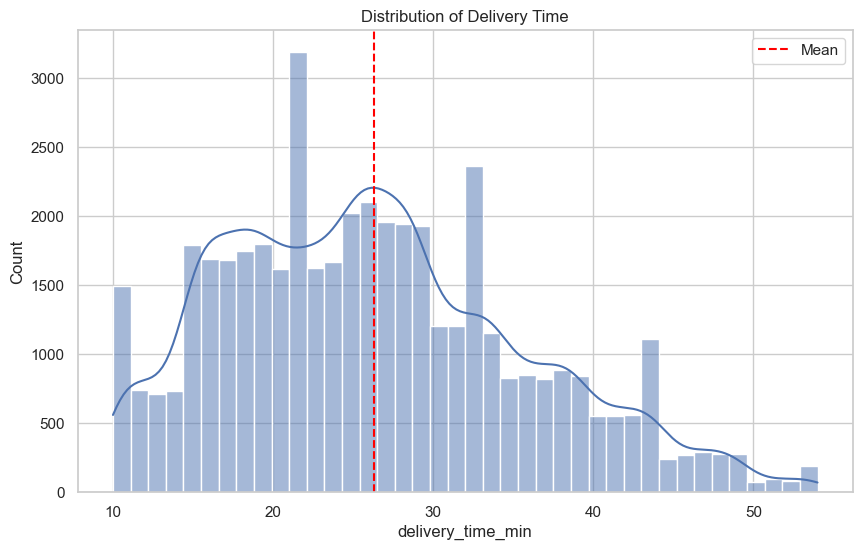

In [173]:
plt.figure(figsize=(10,6))
sns.histplot(df["delivery_time_min"], bins=40, kde=True)
plt.axvline(df["delivery_time_min"].mean(), color='red', linestyle='--', label='Mean')
plt.title("Distribution of Delivery Time")
plt.legend()
save_plot("eda_delivery_distribution")
plt.show()

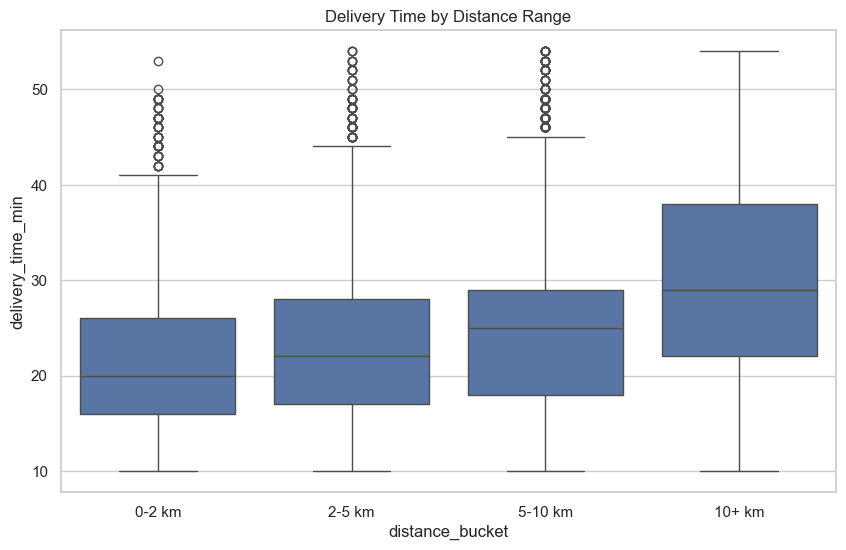

In [174]:
df["distance_bucket"] = pd.cut(
    df["distance_km"],
    bins=[0,2,5,10,20],
    labels=["0-2 km","2-5 km","5-10 km","10+ km"]
)

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="distance_bucket", y="delivery_time_min")
plt.title("Delivery Time by Distance Range")
save_plot("eda_distance_bucket")
plt.show()

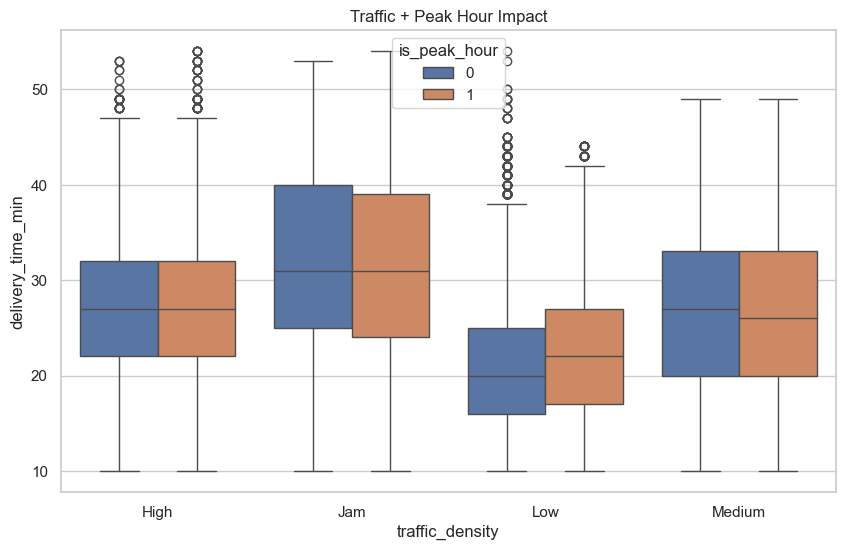

In [175]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="traffic_density",
    y="delivery_time_min",
    hue="is_peak_hour"
)
plt.title("Traffic + Peak Hour Impact")
save_plot("eda_traffic_peak")
plt.show()

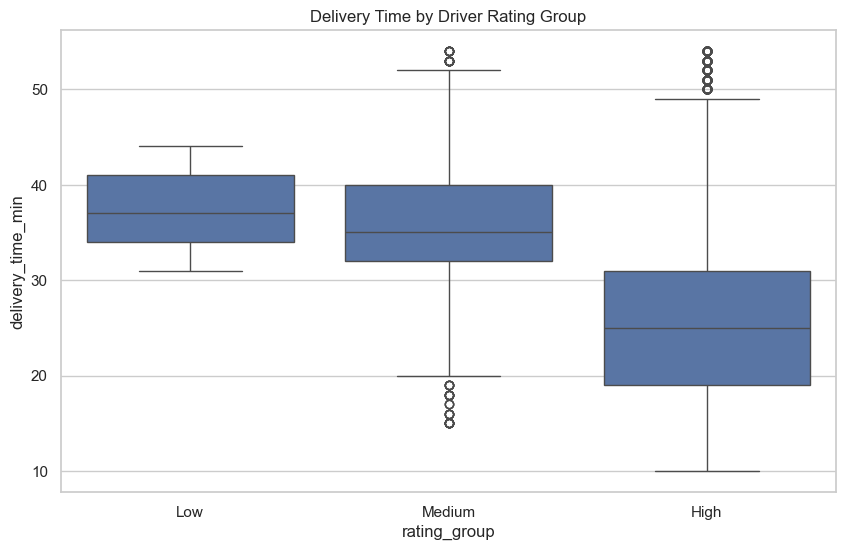

In [176]:
df["rating_group"] = pd.cut(
    df["driver_rating"],
    bins=[0,3,4,5],
    labels=["Low","Medium","High"]
)

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="rating_group", y="delivery_time_min")
plt.title("Delivery Time by Driver Rating Group")
save_plot("eda_driver_group")
plt.show()

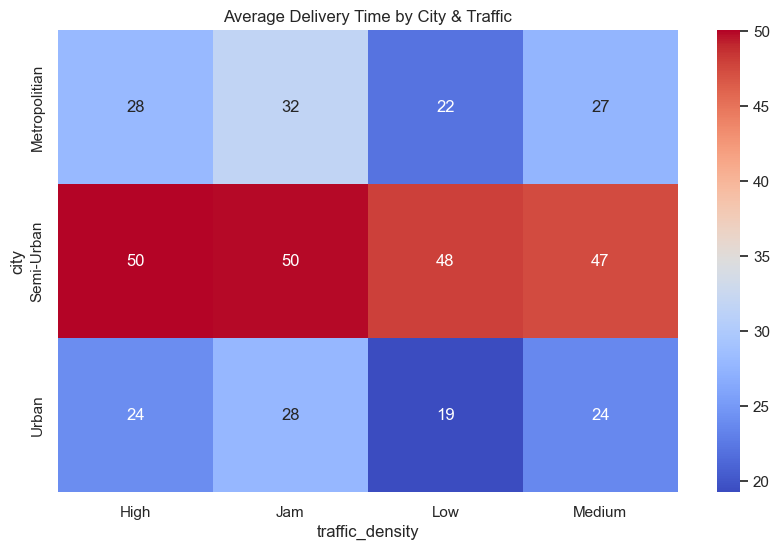

In [177]:
pivot = df.pivot_table(
    values="delivery_time_min",
    index="city",
    columns="traffic_density",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Average Delivery Time by City & Traffic")
save_plot("eda_city_traffic_heatmap")
plt.show()

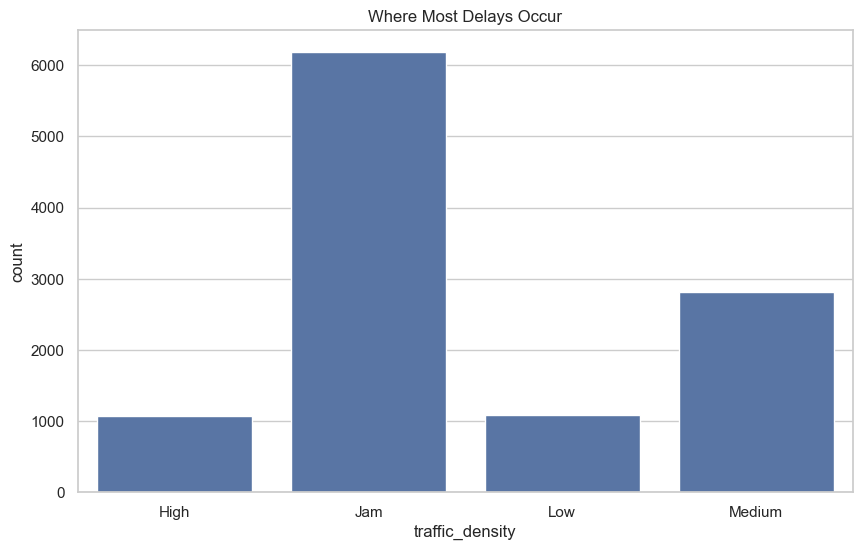

In [180]:
df["delay_flag"] = df["delivery_time_min"] > df["delivery_time_min"].quantile(0.75)

plt.figure(figsize=(10,6))
sns.countplot(data=df[df["delay_flag"]==True], x="traffic_density")
plt.title("Where Most Delays Occur")
save_plot("eda_delay_conditions")
plt.show()

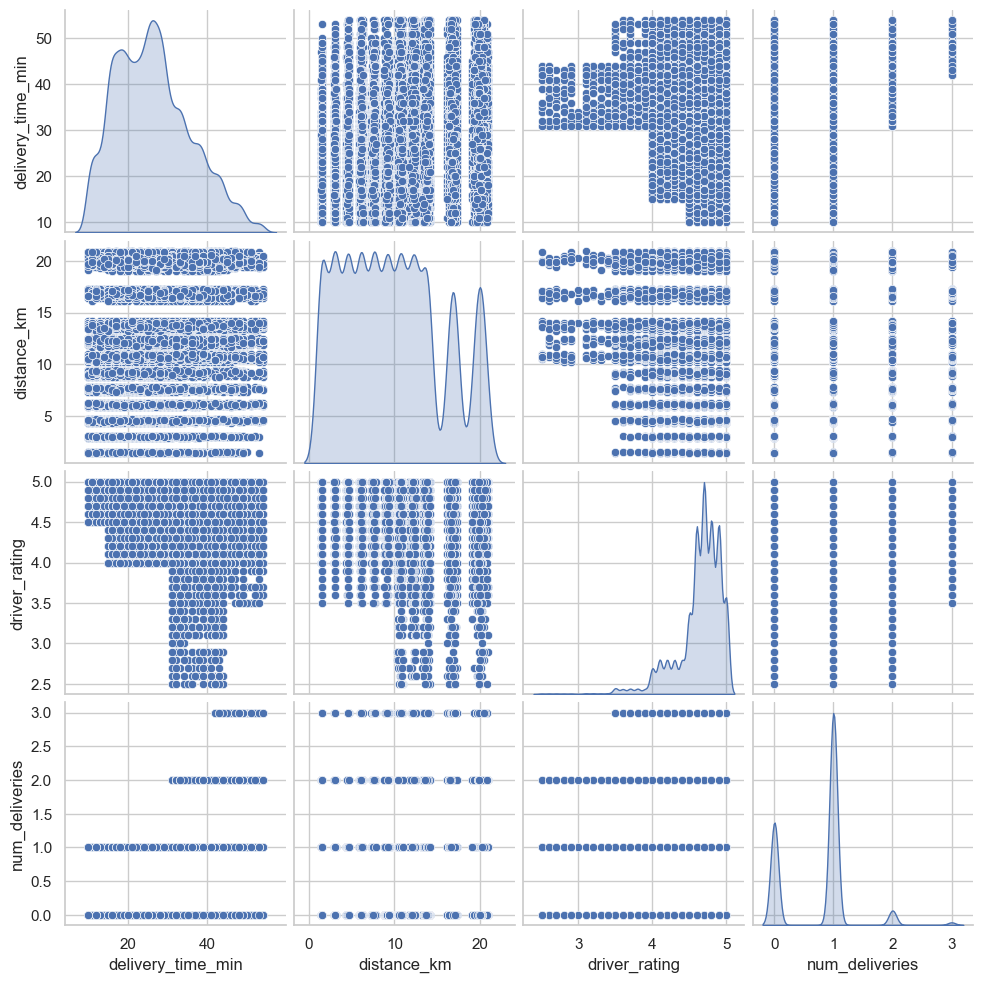

In [181]:
sns.pairplot(
    df[["delivery_time_min","distance_km","driver_rating","num_deliveries"]],
    diag_kind="kde"
)